# VRP Solution Visualization

This notebook demonstrates how to visualize Vehicle Routing Problem (VRP) solutions using the Routing library's built-in visualization tools.

## Setup

First, let's import the required libraries:

In [ ]:
import routing
from routing.constants import Attribute
from routing.visualization import (
    plot_solution,
    plot_problem,
    plot_gantt,
    plot_convergence,
    compare_solutions
)
import matplotlib.pyplot as plt

# Initialize the routing library
routing.init()

# Enable inline plotting
%matplotlib inline

## 1. Create a Sample CVRP Problem

Let's create a Capacitated Vehicle Routing Problem with 15 clients:

In [2]:
import random
random.seed(42)  # For reproducibility

problem = routing.Problem()

# Add depot at center
depot = problem.add_depot(0)
depot.add_attribute(Attribute.GEONODE, x=50, y=50)

# Add clients with random locations and demands
for i in range(1, 16):
    client = problem.add_client(i)
    x = random.uniform(0, 100)
    y = random.uniform(0, 100)
    demand = random.randint(5, 20)
    client.add_attribute(Attribute.GEONODE, x=x, y=y)
    client.add_attribute(Attribute.CONSUMER, demand=demand)

# Add 3 vehicles with capacity 50 each
for v in range(3):
    vehicle = problem.add_vehicle(v)
    vehicle.add_attribute(Attribute.STOCK, capacity=50)

print(f"Problem: {problem.num_clients} clients, {problem.num_vehicles} vehicles")
print(f"Total demand: {problem.total_demand}")
print(f"Total capacity: {problem.total_capacity}")

Problem: 15 clients, 3 vehicles
Total demand: 164
Total capacity: 150


## 2. Visualize the Problem

Before solving, let's visualize the problem to see the client locations and demands:

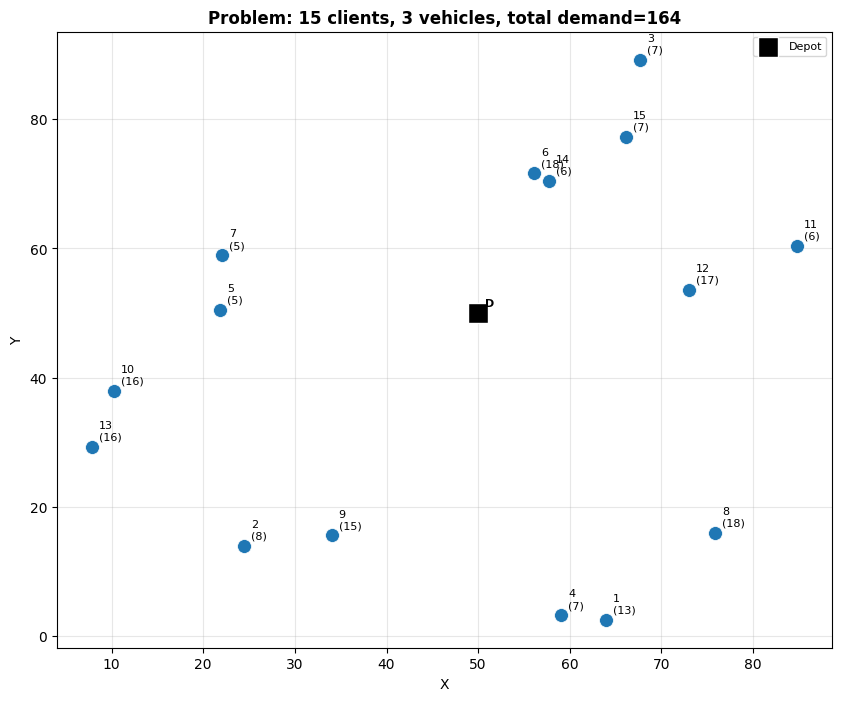

In [3]:
fig, ax = plot_problem(problem, show_demand=True, figsize=(10, 8))
plt.show()

## 3. Solve and Visualize the Solution

Now let's solve the problem and visualize the routes:

In [4]:
# Solve with Genetic Algorithm
solution = routing.solve(problem, "ga", timeout=10)

if solution:
    print(f"Solution found!")
    print(f"Total cost: {solution.cost:.2f}")
    print(f"Number of routes: {solution.num_tours}")
    print(f"Feasible: {solution.is_feasible}")
    print()
    
    # Print route details
    for i, tour in enumerate(solution.get_tours()):
        client_ids = tour.get_client_ids()
        if client_ids:
            print(f"Route {i+1}: {client_ids} (cost: {tour.cost:.2f})")
else:
    print("No solution found")

Solution found!
Total cost: inf
Number of routes: 3
Feasible: False

Route 1: [6, 4, 14, 9] (cost: 256.02)
Route 2: [5, 2, 3, 11, 12, 7] (cost: 279.24)
Route 3: [8, 15, 1] (cost: 229.21)


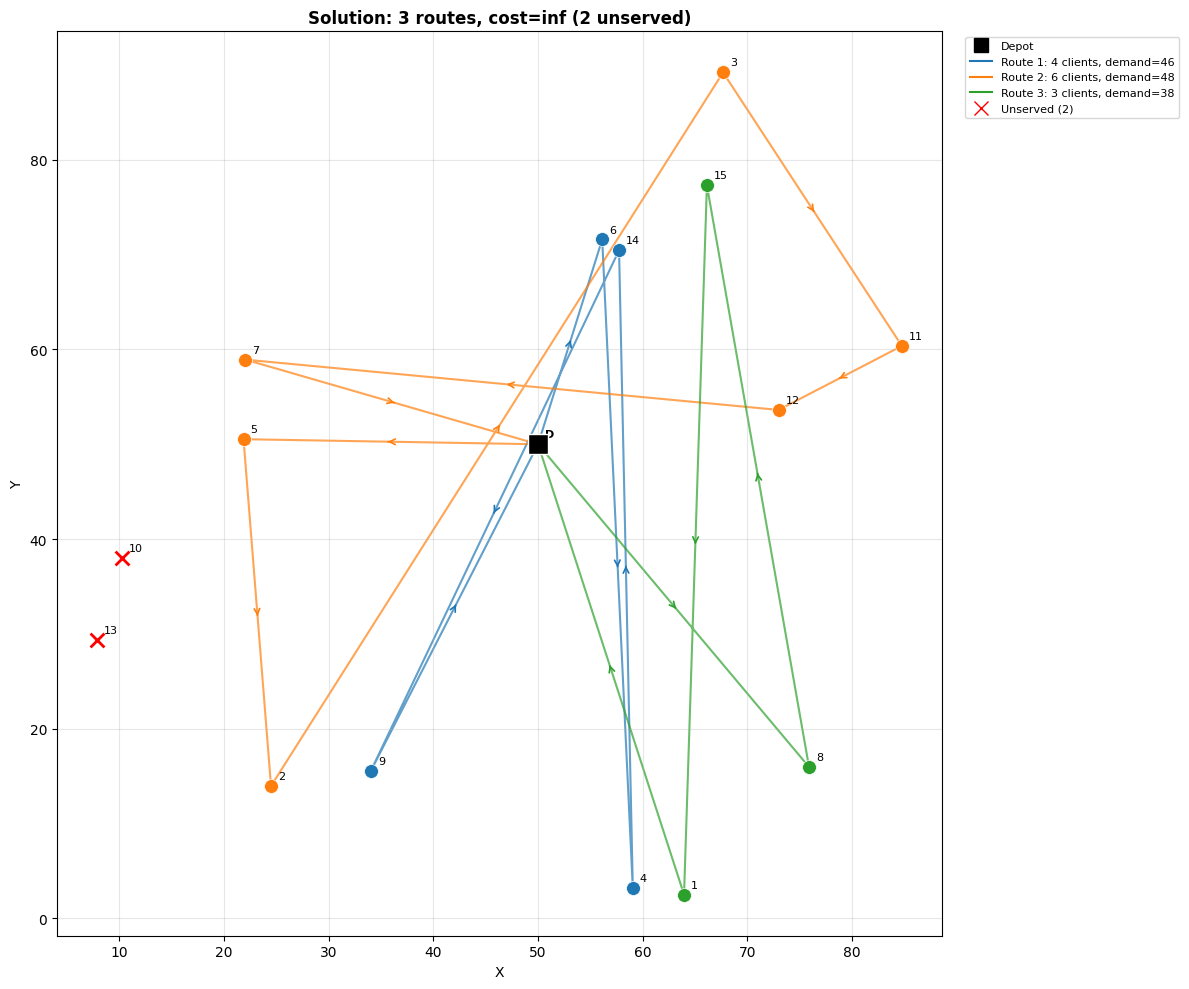

In [5]:
# Visualize the solution
fig, ax = plot_solution(problem, solution, figsize=(12, 10))
plt.show()

## 4. Customizing the Visualization

The `plot_solution` function offers many customization options:

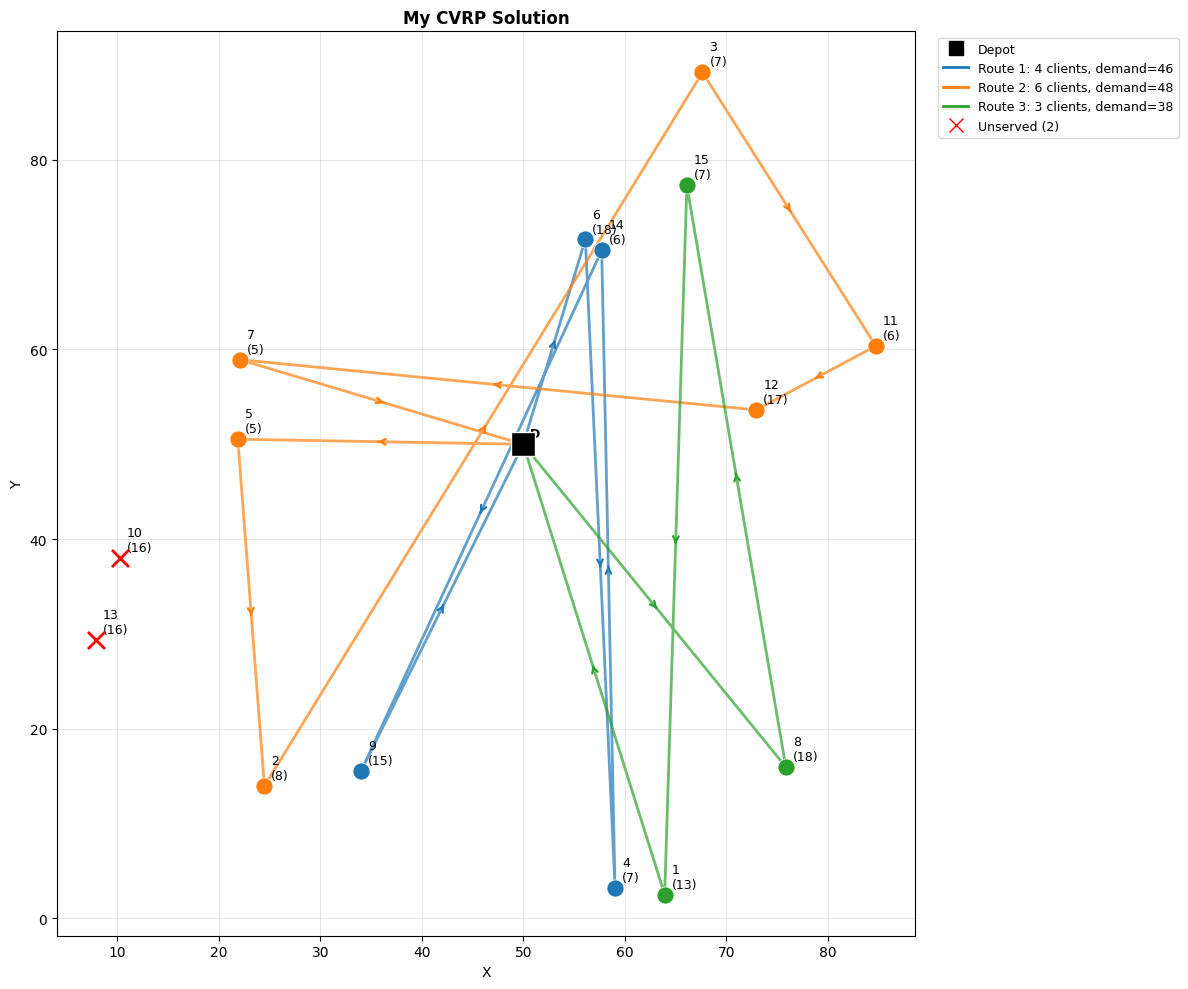

In [6]:
# Customized visualization
fig, ax = plot_solution(
    problem, 
    solution,
    figsize=(12, 10),
    title="My CVRP Solution",
    show_demand=True,      # Show demand values
    show_arrows=True,      # Show direction arrows
    route_width=2.0,       # Thicker route lines
    client_size=150,       # Larger client markers
    depot_size=300,        # Larger depot marker
    font_size=9,           # Larger labels
)
plt.show()

## 5. Tracking Convergence

Use callbacks to track the solver's progress and plot the convergence curve:

In [7]:
# Track costs during solving
costs = []

def on_improvement(solution, cost):
    """Callback function called when solver finds a better solution."""
    costs.append(cost)
    print(f"Improvement #{len(costs)}: cost = {cost:.2f}")

# Solve with callback
solution = routing.solve_with_callback(
    problem,
    on_improvement,
    solver_type="ga",
    timeout=15
)

print(f"\nFinal cost: {solution.cost:.2f}")
print(f"Total improvements: {len(costs)}")


Final cost: inf
Total improvements: 0


In [8]:
# Plot convergence curve
if costs:
    fig, ax = plot_convergence(
        costs,
        title="GA Convergence",
        xlabel="Improvement #",
        figsize=(10, 6)
    )
    plt.show()

## 6. Comparing Different Solvers

Let's compare solutions from different solvers side by side:

In [9]:
# Solve with different solvers
print("Solving with GA...")
sol_ga = routing.solve(problem, "ga", timeout=10)
print(f"  GA cost: {sol_ga.cost:.2f}" if sol_ga else "  No solution")

print("Solving with ALNS...")
sol_alns = routing.solve(problem, "alns", timeout=10)
print(f"  ALNS cost: {sol_alns.cost:.2f}" if sol_alns else "  No solution")

print("Solving with VNS...")
sol_vns = routing.solve(problem, "vns", timeout=10)
print(f"  VNS cost: {sol_vns.cost:.2f}" if sol_vns else "  No solution")

Solving with GA...
  GA cost: inf
Solving with ALNS...
  ALNS cost: 83.10
Solving with VNS...
  VNS cost: 204.26
New best: 254.018
New best: 83.1033
	83.1033
Solution:
  Cost: 83.1033
  Tours: 1
    Tour 0: 10 10 10 
  Unserved: 0
204.258
	204.258
Solution:
  Cost: 204.258
  Tours: 1
    Tour 0: 6 11 4 5 
  Unserved: 0


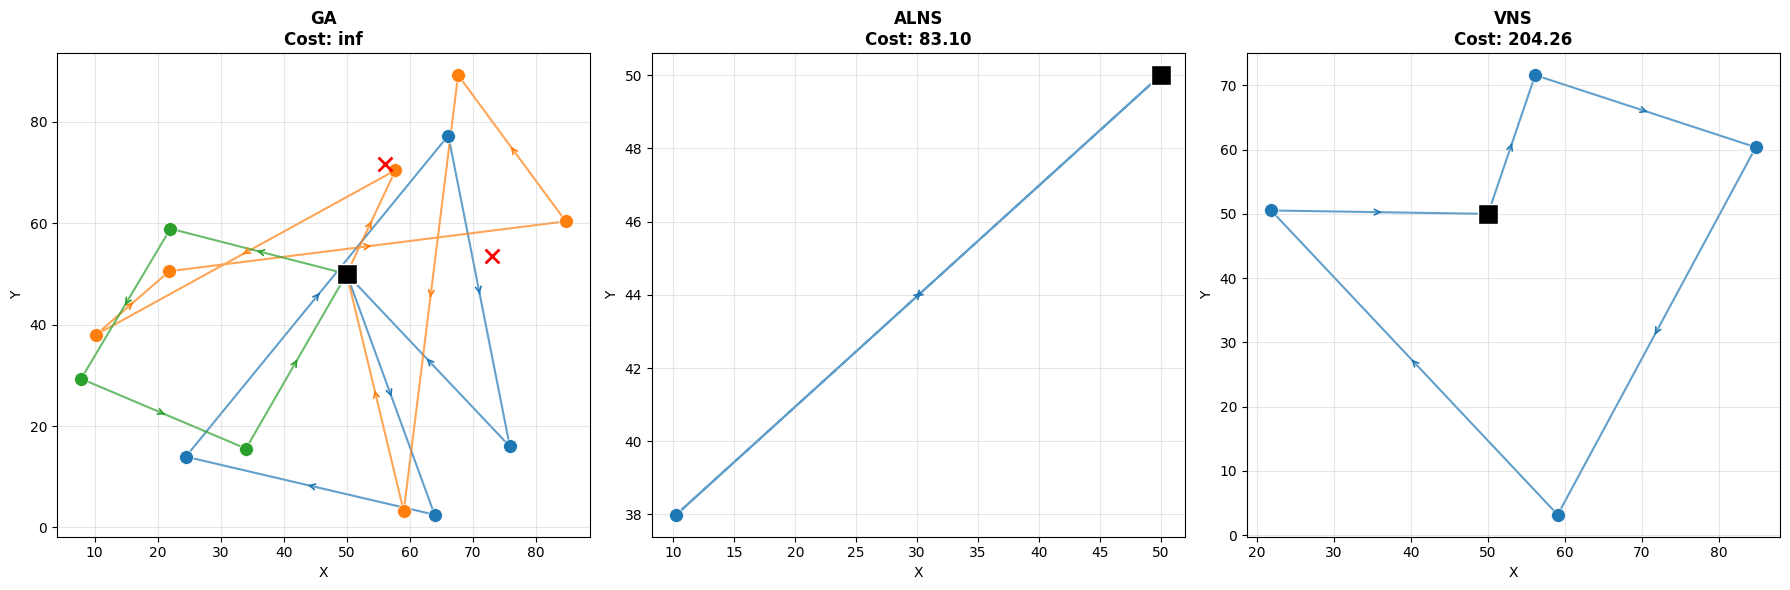

In [10]:
# Compare solutions side by side
solutions = {
    "GA": sol_ga,
    "ALNS": sol_alns,
    "VNS": sol_vns,
}

fig, axes = compare_solutions(
    problem,
    solutions,
    figsize=(18, 6),
    show_labels=False,  # Hide labels for cleaner comparison
)
plt.show()

## 7. Gantt Chart for Time Windows (VRPTW)

For problems with time windows, we can visualize the schedule using a Gantt chart. Let's create a VRPTW problem first:

In [ ]:
# Create a VRPTW problem with time windows
random.seed(123)

vrptw_problem = routing.Problem()

# Depot with time window
depot = vrptw_problem.add_depot(0)
depot.add_attribute(Attribute.GEONODE, x=50, y=50)
depot.add_attribute(Attribute.RENDEZVOUS, open=0, close=500)

# Add clients with locations, demands, time windows, and service times
time_windows = [
    (0, 100), (50, 150), (100, 200), (150, 250), (200, 300),
    (0, 120), (80, 180), (120, 220), (180, 280), (250, 350)
]

for i in range(1, 11):
    client = vrptw_problem.add_client(i)
    x = random.uniform(10, 90)
    y = random.uniform(10, 90)
    demand = random.randint(5, 15)
    tw_open, tw_close = time_windows[i - 1]
    service_time = random.randint(10, 20)
    
    client.add_attribute(Attribute.GEONODE, x=x, y=y)
    client.add_attribute(Attribute.CONSUMER, demand=demand)
    client.add_attribute(Attribute.RENDEZVOUS, open=tw_open, close=tw_close)
    client.add_attribute(Attribute.SERVICE_QUERY, service_time=service_time)

# Add vehicles
for v in range(3):
    vehicle = vrptw_problem.add_vehicle(v)
    vehicle.add_attribute(Attribute.STOCK, capacity=50)

print(f"VRPTW Problem: {vrptw_problem.num_clients} clients with time windows")

# Solve with GA
vrptw_solution = routing.solve(vrptw_problem, "ga", timeout=10)
print(f"Solution cost: {vrptw_solution.cost:.2f}" if vrptw_solution else "No solution")

In [ ]:
# Plot the Gantt chart showing time windows and schedules
fig, ax = plot_gantt(
    vrptw_problem, 
    vrptw_solution,
    figsize=(14, 6),
    show_travel=True,      # Show travel time bars
    show_tw_bounds=True,   # Show time window boundaries
    speed=1.0,             # Travel speed (distance/time)
    title="VRPTW Schedule with Time Windows"
)
plt.show()

The Gantt chart shows:
- **Gray bars**: Time window constraints [open, close] for each client
- **Colored bars**: Service time at each client (color-coded by route)
- **Thin gray bars**: Travel time between clients
- **Labels**: Client IDs on each service bar

Let's also show the routes alongside the schedule:

In [ ]:
# Side-by-side: routes and schedule
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Left: Route visualization
plot_solution(vrptw_problem, vrptw_solution, ax=ax1, 
              title="Routes", show_legend=False)

# Right: Gantt chart
plot_gantt(vrptw_problem, vrptw_solution, ax=ax2,
           title="Schedule", show_tw_bounds=False)

plt.tight_layout()
plt.show()

## 8. Loading and Visualizing Benchmark Instances

You can also load standard benchmark instances and visualize them:

In [11]:
# Note: Adjust the path to your data directory
# Uncomment and modify if you have Solomon instances available:

# problem_solomon = routing.load_solomon("data/CVRPTW/Solomon/25/c101.txt")
# print(f"Loaded: {problem_solomon.num_clients} clients")
# 
# fig, ax = plot_problem(problem_solomon, show_demand=True)
# plt.title("Solomon C101 Instance")
# plt.show()

## 9. Saving Visualizations

Save plots to files for reports or presentations:

Saved to cvrp_solution.png
Saved to cvrp_solution.pdf


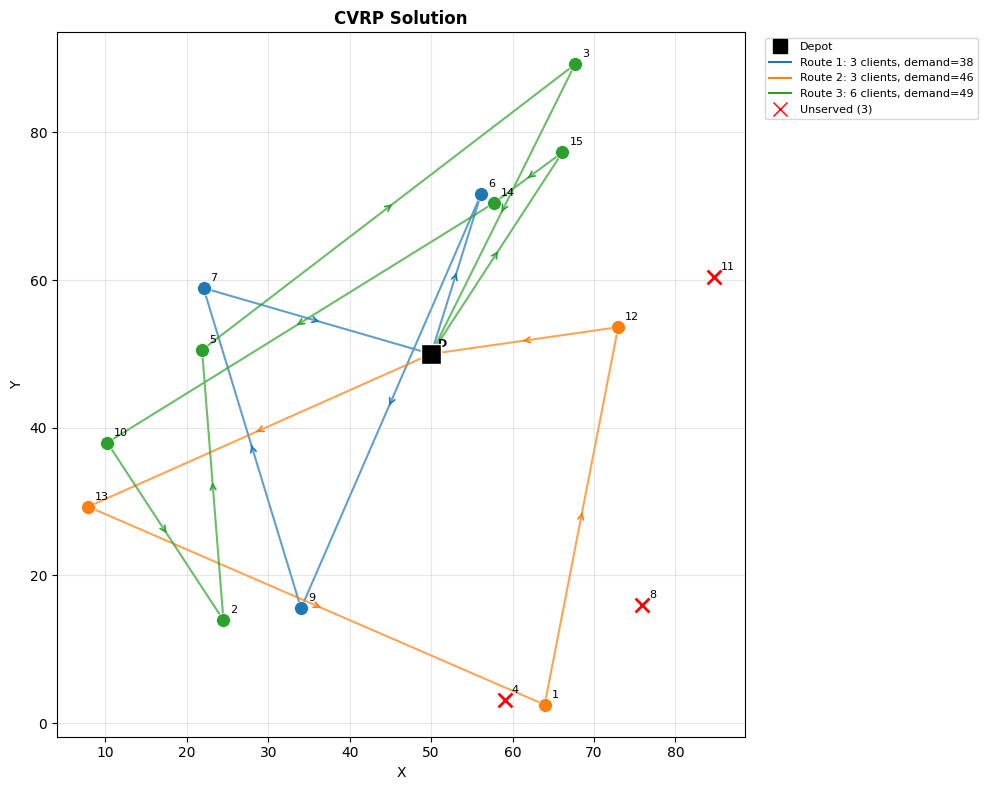

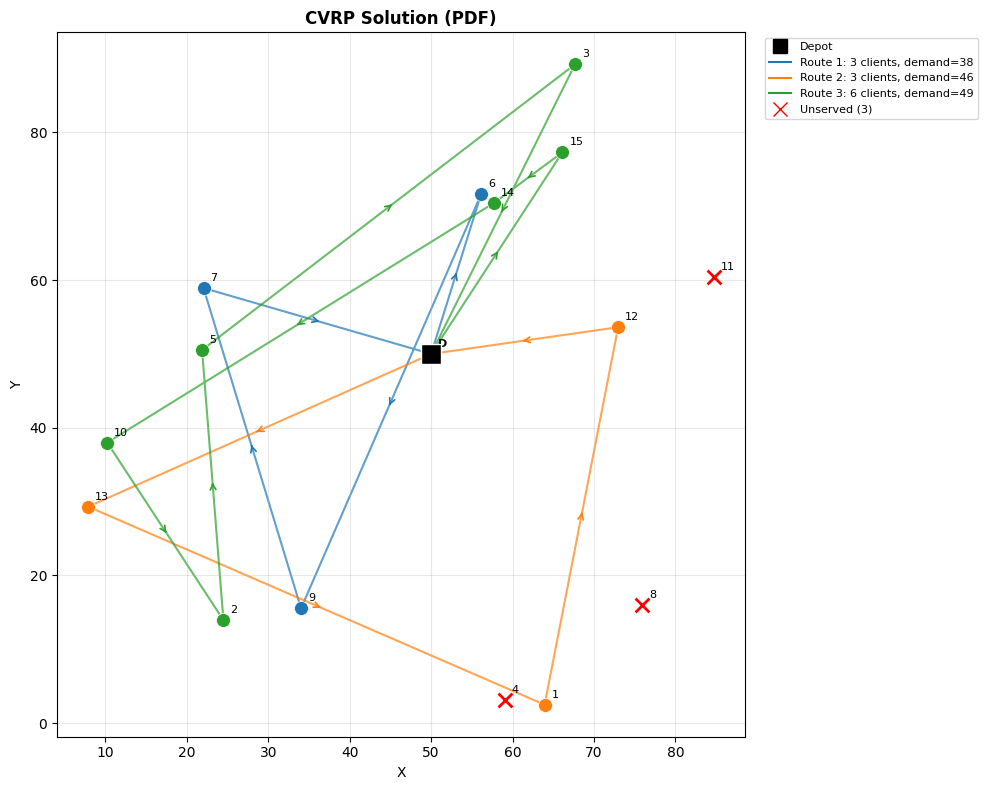

In [12]:
# Save to file
fig, ax = plot_solution(
    problem,
    solution,
    title="CVRP Solution",
    save_path="cvrp_solution.png",
    dpi=200
)
print("Saved to cvrp_solution.png")

# Also available as PDF
fig, ax = plot_solution(
    problem,
    solution,
    title="CVRP Solution (PDF)",
    save_path="cvrp_solution.pdf"
)
print("Saved to cvrp_solution.pdf")

## Summary

The visualization module provides:

- **`plot_problem()`** - Visualize problem instances (clients, depot, demands)
- **`plot_solution()`** - Visualize solutions with colored routes
- **`plot_gantt()`** - Gantt chart for time windows (VRPTW schedules)
- **`plot_convergence()`** - Plot solver convergence curves
- **`compare_solutions()`** - Side-by-side solver comparison

All functions support extensive customization and can save to various file formats.